In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load dataset
df = pd.read_csv('Diwali Sales Data.csv', encoding='unicode_escape')
print(f'Dataset Shape: {df.shape}')

Dataset Shape: (11251, 15)


In [3]:
# Dataset Info 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [4]:
# Statistical summary of numeric columns
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount,Status,unnamed1
count,1.125100e+04,11251.000000,11251.000000,11251.000000,11239.000000,0.0,0.0
mean,1.003004e+06,35.421207,0.420318,2.489290,9453.610858,NaN,NaN
std,1.716125e+03,12.754122,0.493632,1.115047,5222.355869,NaN,NaN
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000,NaN,NaN
25%,1.001492e+06,27.000000,0.000000,1.500000,5443.000000,NaN,NaN
50%,1.003065e+06,33.000000,0.000000,2.000000,8109.000000,NaN,NaN
75%,1.004430e+06,43.000000,1.000000,3.000000,12675.000000,NaN,NaN
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000,NaN,NaN


In [5]:
# Check missing values
print(df.isnull().sum())

User_ID                 0
Cust_name               0
Product_ID              0
Gender                  0
Age Group               0
Age                     0
Marital_Status          0
State                   0
Zone                    0
Occupation              0
Product_Category        0
Orders                  0
Amount                 12
Status              11251
unnamed1            11251
dtype: int64


In [6]:
# Check unique values in key categorical columns
cat_cols = ['Gender', 'Age Group', 'Zone', 'State', 'Occupation', 'Product_Category']
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values")
    print(df[col].unique(), "\n")

Gender: 2 unique values
['F' 'M'] 

Age Group: 7 unique values
['26-35' '0-17' '18-25' '55+' '46-50' '51-55' '36-45'] 

Zone: 5 unique values
['Western' 'Southern' 'Central' 'Northern' 'Eastern'] 

State: 16 unique values
['Maharashtra' 'Andhra\xa0Pradesh' 'Uttar Pradesh' 'Karnataka' 'Gujarat'
 'Himachal Pradesh' 'Delhi' 'Madhya Pradesh' 'Jharkhand' 'Kerala'
 'Haryana' 'Bihar' 'Rajasthan' 'Uttarakhand' 'Telangana' 'Punjab'] 

Occupation: 15 unique values
['Healthcare' 'Govt' 'Automobile' 'Construction' 'Food Processing'
 'Lawyer' 'IT Sector' 'Media' 'Banking' 'Retail' 'Hospitality' 'Aviation'
 'Agriculture' 'Textile' 'Chemical'] 

Product_Category: 18 unique values
['Auto' 'Hand & Power Tools' 'Stationery' 'Tupperware' 'Footwear & Shoes'
 'Furniture' 'Food' 'Games & Toys' 'Sports Products' 'Books'
 'Electronics & Gadgets' 'Decor' 'Clothing & Apparel' 'Beauty'
 'Household items' 'Pet Care' 'Veterinary' 'Office'] 



In [7]:
# Drop irrelevant columns
df.drop(columns=['Status', 'unnamed1'], inplace=True)
print(f'Remaining columns: {df.columns.tolist()}')

Remaining columns: ['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age', 'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category', 'Orders', 'Amount']


In [8]:
# Data cleaning 
df.dropna(inplace=True)

# Convert Amount to integer
df['Amount'] = df['Amount'].astype(int)

# Map Marital_Status for readability
df['Marital_Label'] = df['Marital_Status'].map({0: 'Single', 1: 'Married'})

print(f'Final Dataset Shape: {df.shape}')

Final Dataset Shape: (11239, 14)


In [9]:
# Final cleaned dataset preview
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Marital_Label
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952,Single
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934,Married
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924,Married
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912,Single
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877,Married


In [10]:
# Key business metrics
total_revenue    = df['Amount'].sum()
total_orders     = df['Orders'].sum()
unique_customers = df['User_ID'].nunique()
avg_order_value  = df['Amount'].mean()

print(f'Total Revenue    : ₹{total_revenue:,}')
print(f'Total Orders     : {total_orders:,}')
print(f'Unique Customers : {unique_customers:,}')
print(f'Avg Order Value  : ₹{avg_order_value:,.0f}')

Total Revenue    : ₹106,249,129
Total Orders     : 27,981
Unique Customers : 3,752
Avg Order Value  : ₹9,454


In [11]:
# Gender-wise sales summary
gender_df = df.groupby('Gender').agg(
    Total_Revenue = ('Amount', 'sum'),
    Order_Count   = ('Orders', 'count'),
    Avg_Spend     = ('Amount', 'mean')
).reset_index()

gender_df['Avg_Spend'] = gender_df['Avg_Spend'].round(0).astype(int)
print('Gender-wise Sales Summary:')
gender_df

Gender-wise Sales Summary:


,Gender,Total_Revenue,Order_Count,Avg_Spend
0,F,74335853,7832,9491
1,M,31913276,3407,9367


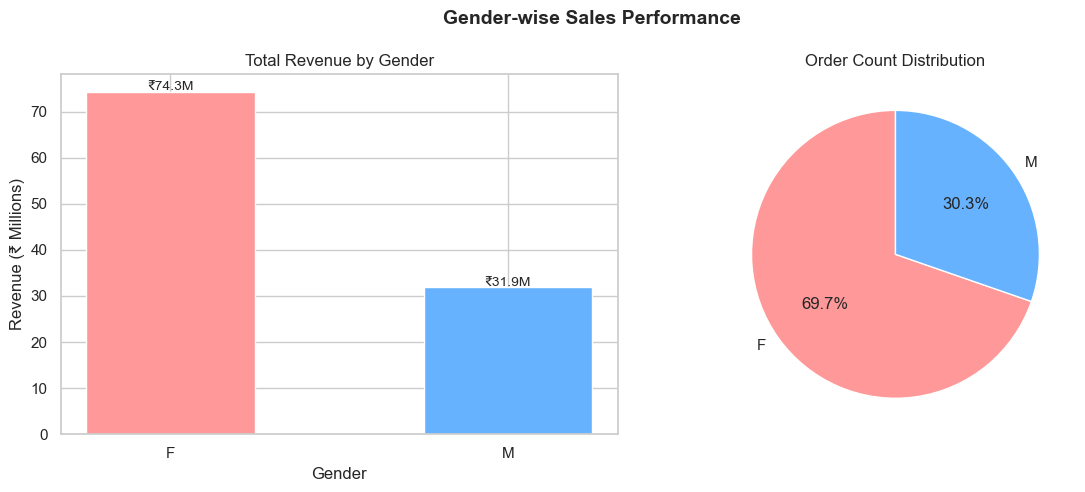

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Gender-wise Sales Performance', fontsize=14, fontweight='bold')

colors = ['#FF9999', '#66B2FF']

# Chart 1: Total Revenue by Gender
bars = axes[0].bar(gender_df['Gender'], gender_df['Total_Revenue'] / 1e6,
                   color=colors, width=0.5)
axes[0].set_title('Total Revenue by Gender')
axes[0].set_ylabel('Revenue (₹ Millions)')
axes[0].set_xlabel('Gender')
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.3,
                 f'₹{h:.1f}M', ha='center', fontsize=10)

# Chart 2: Order Count Distribution
axes[1].pie(gender_df['Order_Count'],
            labels=gender_df['Gender'],
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Order Count Distribution')

plt.tight_layout()
plt.show()

In [13]:
# Age group-wise sales summary
age_order = ['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+']

age_df = df.groupby('Age Group').agg(
    Total_Revenue = ('Amount', 'sum'),
    Order_Count   = ('Orders', 'count'),
    Avg_Spend     = ('Amount', 'mean')
).reindex(age_order).reset_index()

age_df['Avg_Spend'] = age_df['Avg_Spend'].round(0).astype(int)
print('Age Group-wise Sales Summary:')
age_df

Age Group-wise Sales Summary:


,Age Group,Total_Revenue,Order_Count,Avg_Spend
0,0-17,2699653,296,9120
1,18-25,17240732,1879,9175
2,26-35,42613442,4541,9384
3,36-45,22144994,2283,9700
4,46-50,9207844,983,9367
5,51-55,8261477,830,9954
6,55+,4080987,427,9557


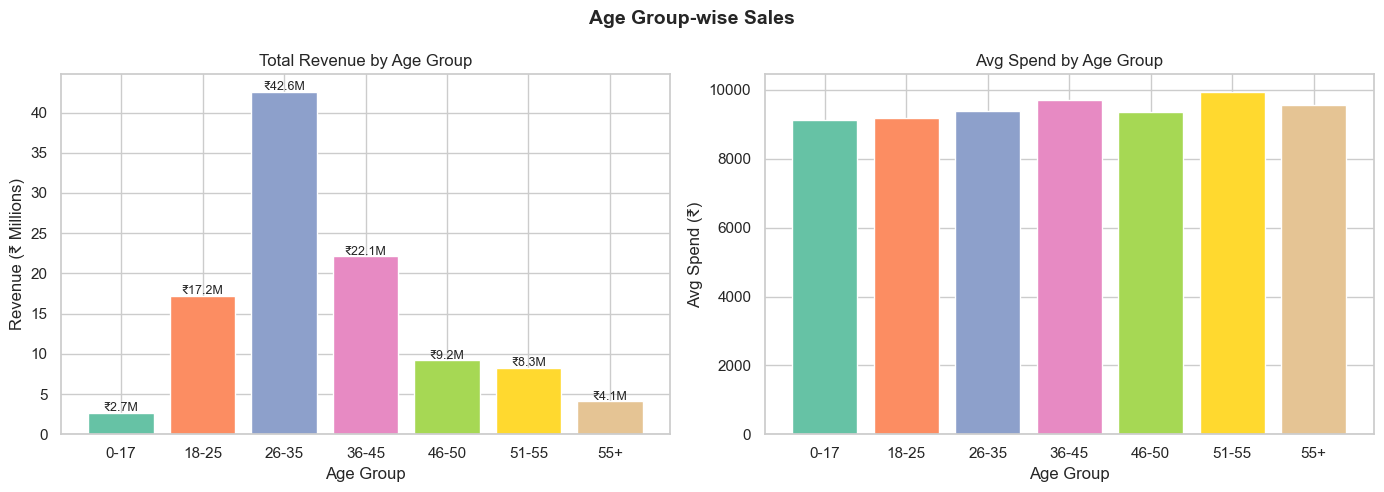

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Age Group-wise Sales', fontsize=14, fontweight='bold')

colors = sns.color_palette('Set2', len(age_order))

# Chart 1: Total Revenue by Age Group
bars = axes[0].bar(age_df['Age Group'], age_df['Total_Revenue'] / 1e6, color=colors)
axes[0].set_title('Total Revenue by Age Group')
axes[0].set_ylabel('Revenue (₹ Millions)')
axes[0].set_xlabel('Age Group')
for bar in bars:
    h = bar.get_height()
    if h > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.2,
                     f'₹{h:.1f}M', ha='center', fontsize=9)

# Chart 2: Avg Spend by Age Group
axes[1].bar(age_df['Age Group'], age_df['Avg_Spend'], color=colors)
axes[1].set_title('Avg Spend by Age Group')
axes[1].set_ylabel('Avg Spend (₹)')
axes[1].set_xlabel('Age Group')

plt.tight_layout()
plt.show()

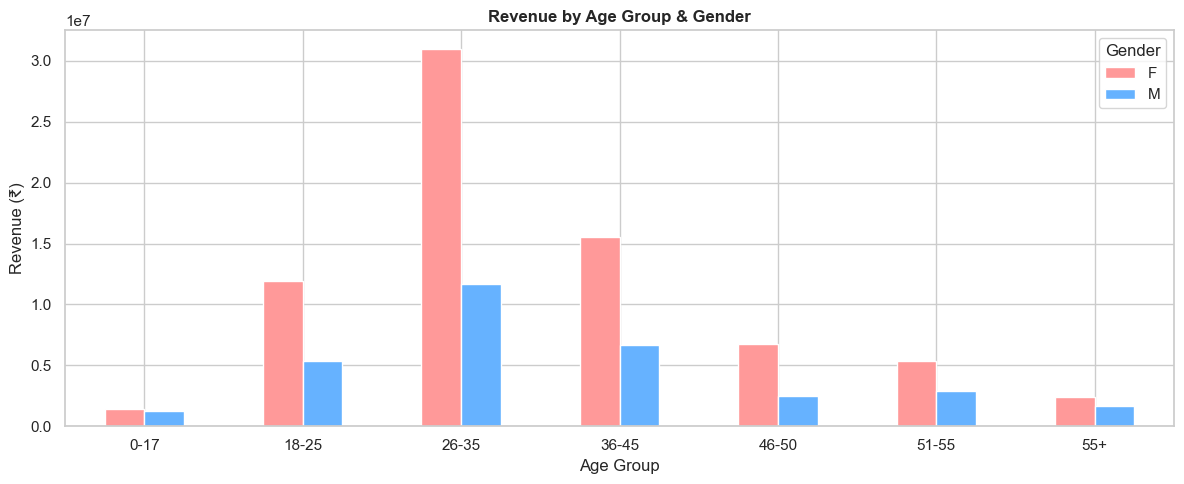

In [15]:
# Revenue breakdown by Age Group and Gender
age_gender = df.groupby(['Age Group', 'Gender'])['Amount'].sum().unstack().reindex(age_order)

age_gender.plot(kind='bar', figsize=(12, 5), color=['#FF9999', '#66B2FF'])
plt.title('Revenue by Age Group & Gender', fontweight='bold')
plt.ylabel('Revenue (₹)')
plt.xlabel('Age Group')
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

In [16]:
# Zone-wise sales summary
zone_df = df.groupby('Zone').agg(
    Total_Revenue = ('Amount', 'sum'),
    Order_Count   = ('Orders', 'count')
).sort_values('Total_Revenue', ascending=False).reset_index()

print('Zone-wise Sales Summary:')
zone_df

Zone-wise Sales Summary:


,Zone,Total_Revenue,Order_Count
0,Central,41600872,4289
1,Southern,26606667,2693
2,Western,18373625,1952
3,Northern,12618752,1491
4,Eastern,7049213,814


In [17]:
# Top 10 states by revenue
state_df = df.groupby('State').agg(
    Total_Revenue = ('Amount', 'sum'),
    Order_Count   = ('Orders', 'count')
).sort_values('Total_Revenue', ascending=False).reset_index()

print('Top 10 States by Revenue:')
state_df.head(10)

Top 10 States by Revenue:


,State,Total_Revenue,Order_Count
0,Uttar Pradesh,19374968,1944
1,Maharashtra,14427543,1525
2,Karnataka,13523540,1304
3,Delhi,11603818,1104
4,Madhya Pradesh,8101142,921
5,Andhra Pradesh,8037146,811
6,Himachal Pradesh,4963368,608
7,Haryana,4220175,452
8,Bihar,4022757,434
9,Gujarat,3946082,427


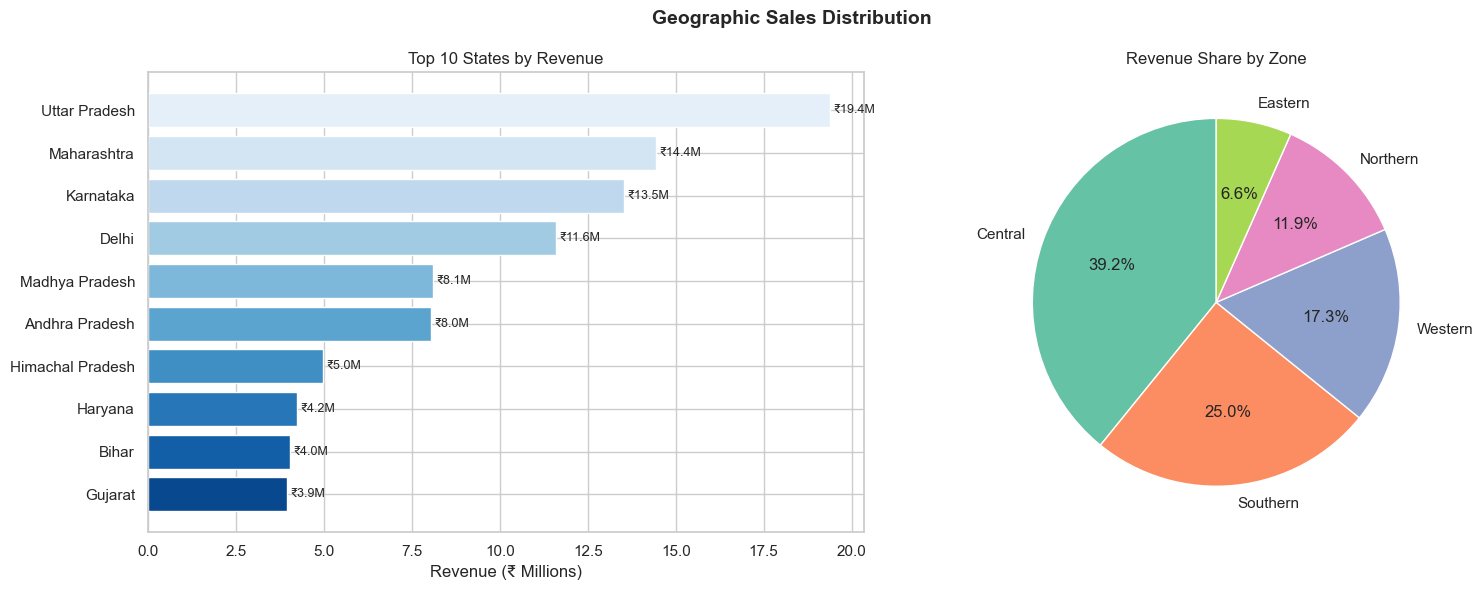

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Geographic Sales Distribution', fontsize=14, fontweight='bold')

# Chart 1: Top 10 States by Revenue
top10 = state_df.head(10)
colors_s = sns.color_palette('Blues_r', 10)
axes[0].barh(top10['State'][::-1], top10['Total_Revenue'][::-1] / 1e6, color=colors_s)
axes[0].set_title('Top 10 States by Revenue')
axes[0].set_xlabel('Revenue (₹ Millions)')
for i, val in enumerate(top10['Total_Revenue'][::-1] / 1e6):
    axes[0].text(val + 0.1, i, f'₹{val:.1f}M', va='center', fontsize=9)

# Chart 2: Revenue Share by Zone
colors_z = sns.color_palette('Set2', len(zone_df))
axes[1].pie(zone_df['Total_Revenue'],
            labels=zone_df['Zone'],
            autopct='%1.1f%%', colors=colors_z, startangle=90)
axes[1].set_title('Revenue Share by Zone')

plt.tight_layout()
plt.show()

In [19]:
# Occupation-wise sales summary
occ_df = df.groupby('Occupation').agg(
    Total_Revenue = ('Amount', 'sum'),
    Order_Count   = ('Orders', 'count'),
    Avg_Spend     = ('Amount', 'mean')
).sort_values('Total_Revenue', ascending=False).reset_index()

occ_df['Avg_Spend'] = occ_df['Avg_Spend'].round(0).astype(int)
print('Occupation-wise Sales Summary:')
occ_df

Occupation-wise Sales Summary:


,Occupation,Total_Revenue,Order_Count,Avg_Spend
0,IT Sector,14755079,1583,9321
1,Healthcare,13034586,1408,9258
2,Aviation,12602298,1310,9620
3,Banking,10770610,1137,9473
4,Govt,8517212,854,9973
5,Hospitality,6376405,703,9070
6,Media,6295832,637,9884
7,Automobile,5368596,565,9502
8,Chemical,5297436,541,9792
9,Lawyer,4981665,531,9382


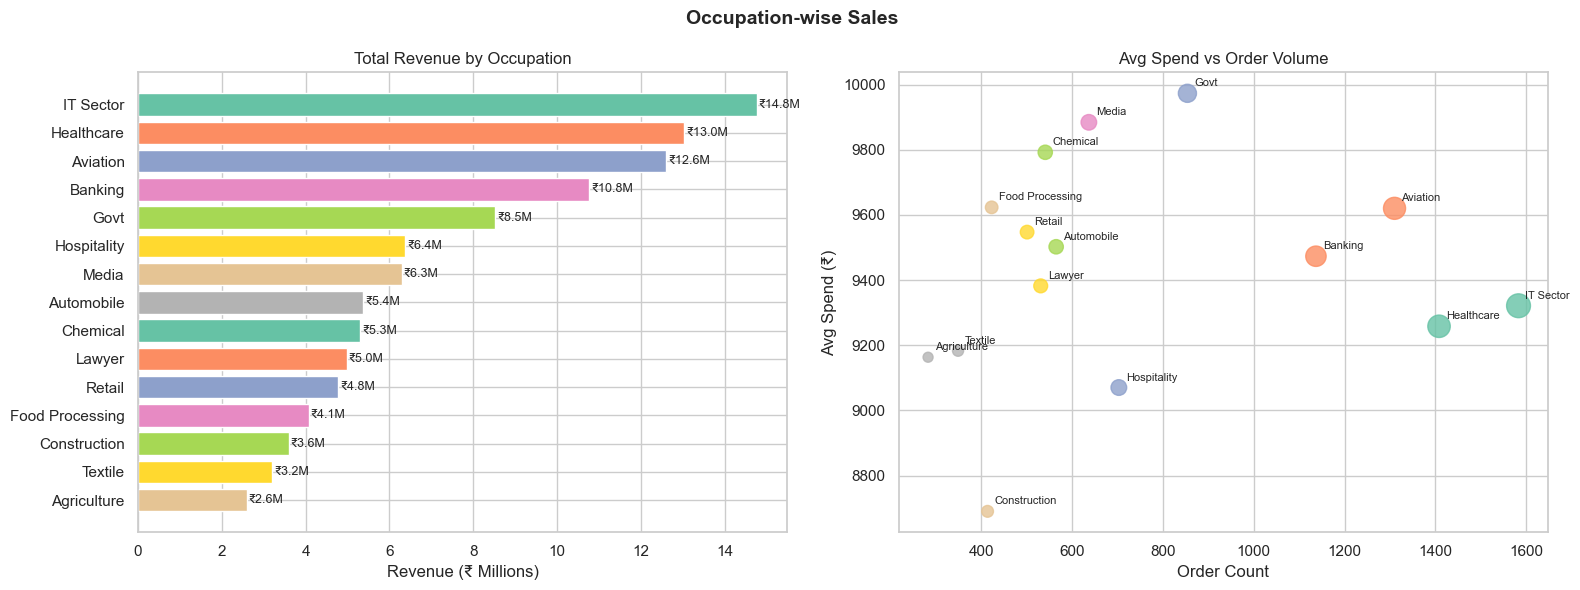

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Occupation-wise Sales', fontsize=14, fontweight='bold')

colors_o = sns.color_palette('Set2', len(occ_df))

# Chart 1: Total Revenue by Occupation
axes[0].barh(occ_df['Occupation'][::-1], occ_df['Total_Revenue'][::-1] / 1e6, color=colors_o[::-1])
axes[0].set_title('Total Revenue by Occupation')
axes[0].set_xlabel('Revenue (₹ Millions)')
for i, val in enumerate(occ_df['Total_Revenue'][::-1] / 1e6):
    axes[0].text(val + 0.05, i, f'₹{val:.1f}M', va='center', fontsize=9)

# Chart 2: Avg Spend vs Order Count
axes[1].scatter(occ_df['Order_Count'], occ_df['Avg_Spend'],
                s=occ_df['Total_Revenue'] / 50000, alpha=0.8,
                c=range(len(occ_df)), cmap='Set2')
for _, row in occ_df.iterrows():
    axes[1].annotate(row['Occupation'], (row['Order_Count'], row['Avg_Spend']),
                     fontsize=8, xytext=(5, 5), textcoords='offset points')
axes[1].set_title('Avg Spend vs Order Volume')
axes[1].set_xlabel('Order Count')
axes[1].set_ylabel('Avg Spend (₹)')

plt.tight_layout()
plt.show()

In [21]:
# Product category-wise sales summary
cat_df = df.groupby('Product_Category').agg(
    Total_Revenue = ('Amount', 'sum'),
    Order_Count   = ('Orders', 'count'),
    Avg_Spend     = ('Amount', 'mean')
).sort_values('Total_Revenue', ascending=False).reset_index()

cat_df['Avg_Spend'] = cat_df['Avg_Spend'].round(0).astype(int)
print('Product Category-wise Sales Summary:')
cat_df

Product Category-wise Sales Summary:


,Product_Category,Total_Revenue,Order_Count,Avg_Spend
0,Food,33933883,2490,13628
1,Clothing & Apparel,16495019,2655,6213
2,Electronics & Gadgets,15643846,2087,7496
3,Footwear & Shoes,15575209,1059,14707
4,Furniture,5440051,352,15455
5,Games & Toys,4331694,386,11222
6,Sports Products,3635933,356,10213
7,Beauty,1959484,422,4643
8,Auto,1958609,97,20192
9,Stationery,1676051,112,14965


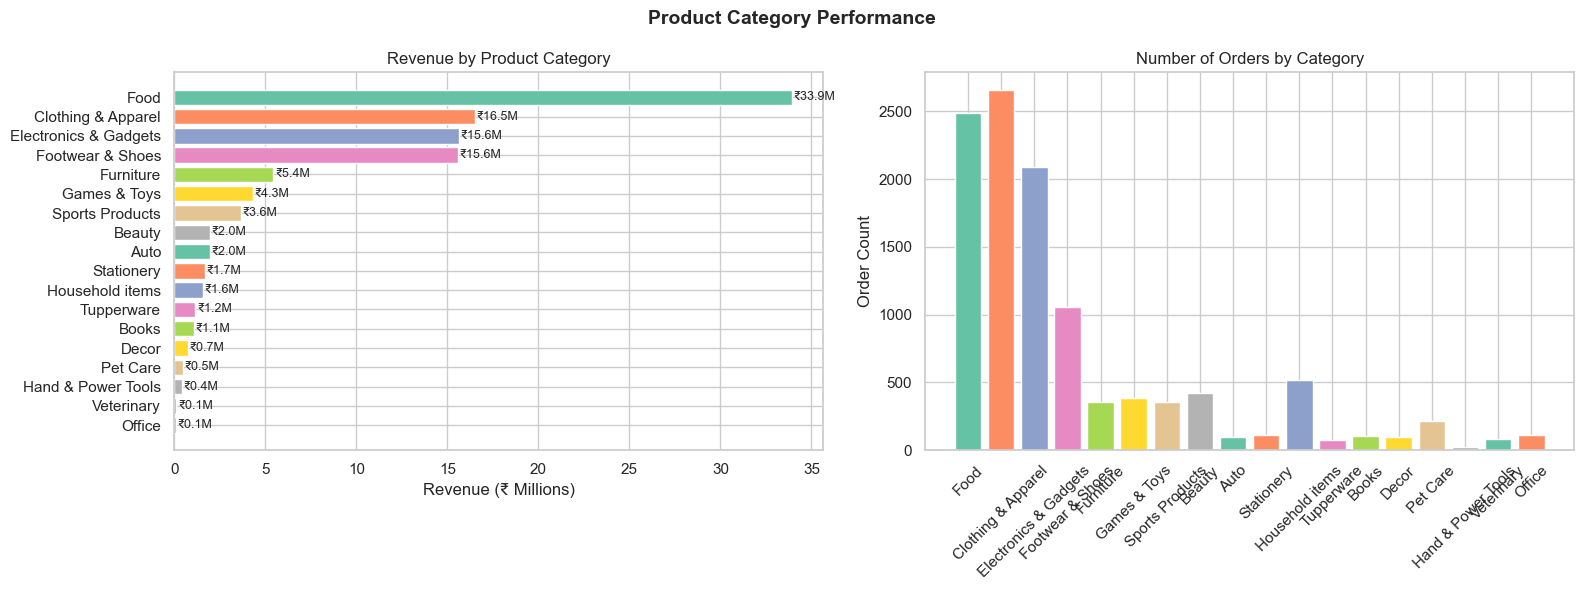

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Product Category Performance', fontsize=14, fontweight='bold')

colors_c = sns.color_palette('Set2', len(cat_df))

# Chart 1: Revenue by Product Category
axes[0].barh(cat_df['Product_Category'][::-1], cat_df['Total_Revenue'][::-1] / 1e6, color=colors_c[::-1])
axes[0].set_title('Revenue by Product Category')
axes[0].set_xlabel('Revenue (₹ Millions)')
for i, val in enumerate(cat_df['Total_Revenue'][::-1] / 1e6):
    axes[0].text(val + 0.1, i, f'₹{val:.1f}M', va='center', fontsize=9)

# Chart 2: Number of Orders by Category
axes[1].bar(cat_df['Product_Category'], cat_df['Order_Count'], color=colors_c)
axes[1].set_title('Number of Orders by Category')
axes[1].set_ylabel('Order Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [23]:
# Top 10 most ordered products
top_products = df.groupby('Product_ID')['Orders'].sum().sort_values(ascending=False).head(10)
print('Top 10 Most Ordered Products:')
print(top_products)

Top 10 Most Ordered Products:
Product_ID
P00265242    127
P00110942    116
P00237542     91
P00184942     82
P00114942     79
P00025442     79
P00117942     76
P00145042     76
P00044442     75
P00110842     74
Name: Orders, dtype: int64


In [24]:
# Revenue by Marital Status and Gender
marital_df = df.groupby(['Marital_Label', 'Gender'])['Amount'].sum().reset_index()
marital_df.columns = ['Marital_Status', 'Gender', 'Total_Revenue']

print('Marital Status & Gender Revenue:')
marital_df

Marital Status & Gender Revenue:


,Marital_Status,Gender,Total_Revenue
0,Married,F,30549207
1,Married,M,13574538
2,Single,F,43786646
3,Single,M,18338738


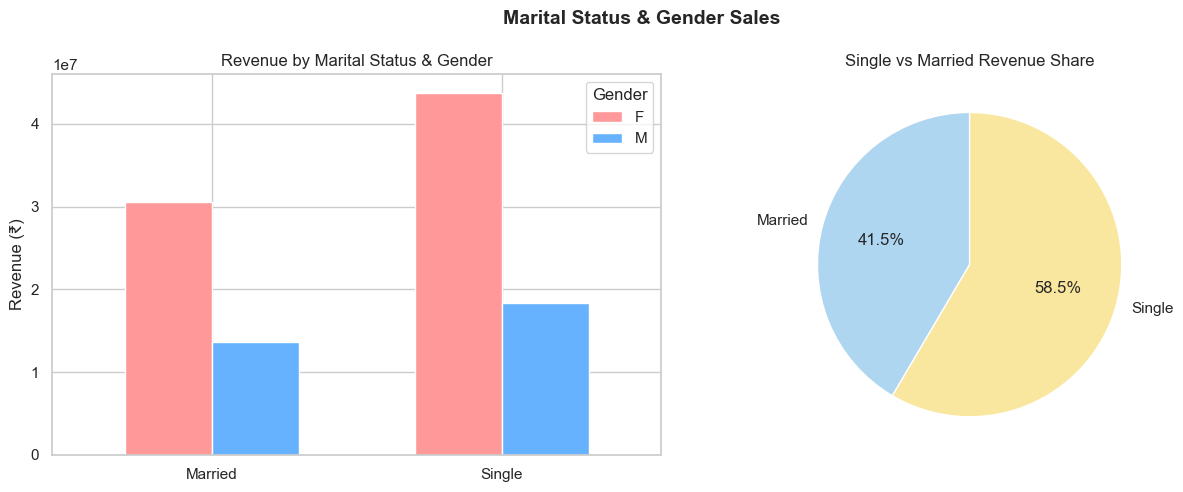

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Marital Status & Gender Sales', fontsize=14, fontweight='bold')

# Chart 1: Revenue by Marital Status & Gender
pivot = marital_df.pivot(index='Marital_Status', columns='Gender', values='Total_Revenue')
pivot.plot(kind='bar', ax=axes[0], color=['#FF9999', '#66B2FF'], width=0.6)
axes[0].set_title('Revenue by Marital Status & Gender')
axes[0].set_ylabel('Revenue (₹)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Gender')

# Chart 2: Single vs Married Revenue Share
marital_total = marital_df.groupby('Marital_Status')['Total_Revenue'].sum().reset_index()
axes[1].pie(marital_total['Total_Revenue'],
            labels=marital_total['Marital_Status'],
            autopct='%1.1f%%', startangle=90,
            colors=['#AED6F1', '#F9E79F'])
axes[1].set_title('Single vs Married Revenue Share')

plt.tight_layout()
plt.show()

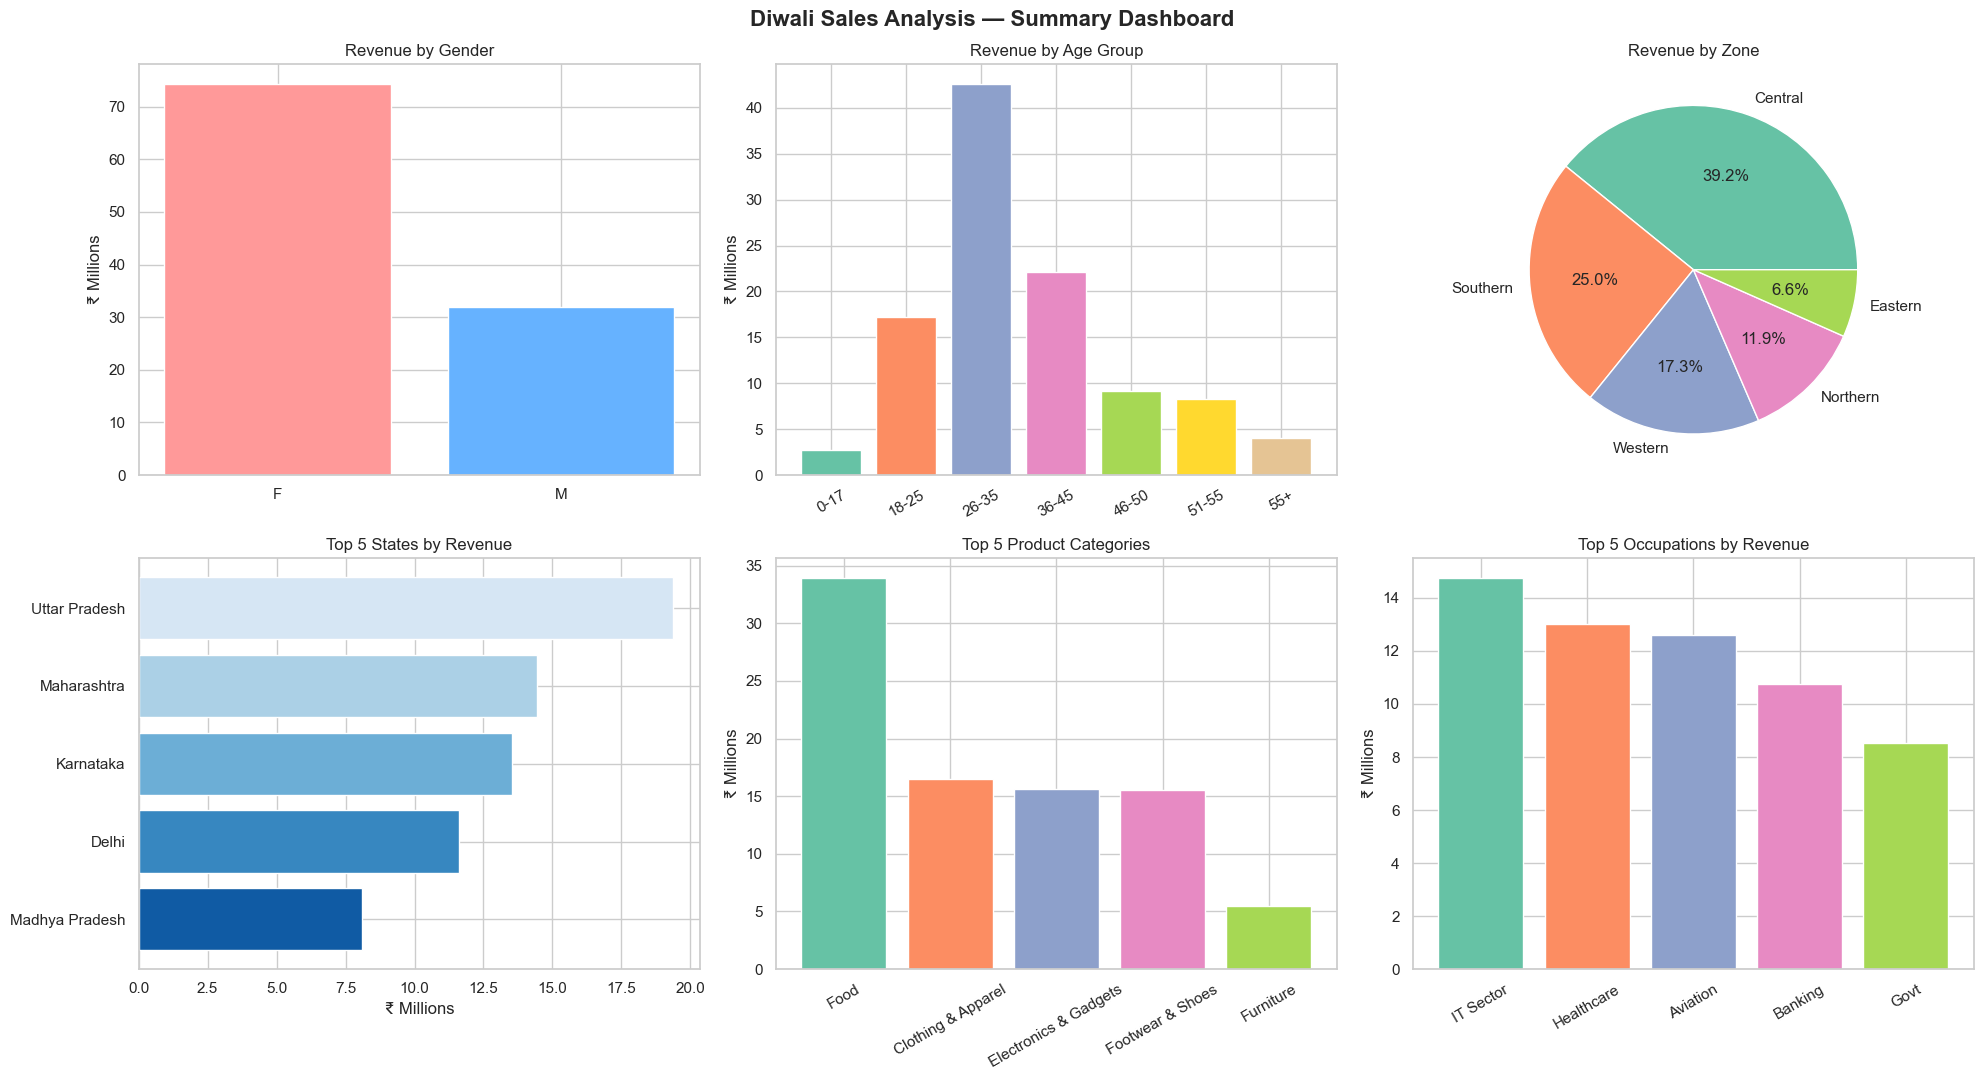

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('Diwali Sales Analysis — Summary Dashboard', fontsize=16, fontweight='bold')

# 1. Revenue by Gender
axes[0,0].bar(gender_df['Gender'], gender_df['Total_Revenue'] / 1e6,
              color=['#FF9999', '#66B2FF'])
axes[0,0].set_title('Revenue by Gender')
axes[0,0].set_ylabel('₹ Millions')

# 2. Revenue by Age Group
axes[0,1].bar(age_df['Age Group'], age_df['Total_Revenue'].fillna(0) / 1e6,
              color=sns.color_palette('Set2', 7))
axes[0,1].set_title('Revenue by Age Group')
axes[0,1].set_ylabel('₹ Millions')
axes[0,1].tick_params(axis='x', rotation=30)

# 3. Revenue by Zone
axes[0,2].pie(zone_df['Total_Revenue'], labels=zone_df['Zone'],
              autopct='%1.1f%%', colors=sns.color_palette('Set2', 5))
axes[0,2].set_title('Revenue by Zone')

# 4. Top 5 States
t5s = state_df.head(5)
axes[1,0].barh(t5s['State'][::-1], t5s['Total_Revenue'][::-1] / 1e6,
               color=sns.color_palette('Blues_r', 5))
axes[1,0].set_title('Top 5 States by Revenue')
axes[1,0].set_xlabel('₹ Millions')

# 5. Top 5 Product Categories
t5c = cat_df.head(5)
axes[1,1].bar(t5c['Product_Category'], t5c['Total_Revenue'] / 1e6,
              color=sns.color_palette('Set2', 5))
axes[1,1].set_title('Top 5 Product Categories')
axes[1,1].set_ylabel('₹ Millions')
axes[1,1].tick_params(axis='x', rotation=30)

# 6. Top 5 Occupations
t5o = occ_df.head(5)
axes[1,2].bar(t5o['Occupation'], t5o['Total_Revenue'] / 1e6,
              color=sns.color_palette('Set2', 5))
axes[1,2].set_title('Top 5 Occupations by Revenue')
axes[1,2].set_ylabel('₹ Millions')
axes[1,2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [29]:
# Marketing Insights based on Analysis

# Gender insight
top_gender = gender_df.loc[gender_df['Total_Revenue'].idxmax(), 'Gender']

# Age group insight
top_age = age_df.loc[age_df['Total_Revenue'].idxmax(), 'Age Group']

# State insight
top_state = state_df.iloc[0]['State']

# Zone insight
top_zone = zone_df.iloc[0]['Zone']

# Occupation insight
top_occupation = occ_df.iloc[0]['Occupation']

# Product insight
top_product = cat_df.iloc[0]['Product_Category']

print("MARKETING RECOMMENDATIONS:")
print(f"- Run {top_gender}-focused Diwali campaigns")
print(f"- Target customers aged {top_age} with special festive offers")
print(f"- Focus advertising budget on {top_state} and {top_zone} zone")
print(f"- Create exclusive deals for {top_occupation} professionals")
print(f"- Stock and promote {top_product} heavily before festive season")

MARKETING RECOMMENDATIONS:
- Run F-focused Diwali campaigns
- Target customers aged 26-35 with special festive offers
- Focus advertising budget on Uttar Pradesh and Central zone
- Create exclusive deals for IT Sector professionals
- Stock and promote Food heavily before festive season
